# Foundation/Housekeeping

Importing Relevant Libraries/Tools

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning

Creating DataFrame and Initial Clean Up

In [108]:
# ensuring excel file is not corrupt

xls = pd.ExcelFile("fixed_excel.xlsx")
print(xls.sheet_names)

['Sheet1']


In [109]:
# creating dataframe
df = pd.read_excel(r"fixed_excel.xlsx") # reads data directly from Excel so the notebook always uses the latest saved version

# standardizing lowercase headers for convenience
df.columns = df.columns.str.lower() # lowercase all headers

# anonomyzing companies
company_dict = {company: f"C{idx:03d}" for idx, company in enumerate(df["company"].unique())} # creating unique id for each company and storing in a dictionary

df["company_id"] = df["company"].map(company_dict) # mapping new ids to company names

df = df.drop(columns=["company"]) # removing original column with real company names

# checking df anonymized dataframe
# df

# Data Cleaning

In [110]:
# checking basic data info: types, total entries, etc...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       20 non-null     object        
 1   application date            19 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   role                        20 non-null     object        
 4   resume                      20 non-null     object        
 5   transcript                  20 non-null     object        
 6   cover letter                20 non-null     object        
 7   ghosted                     5 non-null      object        
 8   round 1                     3 non-null      object        
 9   round 2                     1 non-null      object        
 10  round 3                     0 non-null      float64       
 11  declined                    1 non-null      object        
 

In [113]:
# ensuring type datetime objects are not altered; result dates will eventually become datetime objects as I hear back from employers
columns_lower = [lower for lower in df.columns if lower not in ["application date", "result date"]] # only capturing columns that are not date columns

# altering all columns except "date" to lowercase strings for ease of use and consistency
df[columns_lower] = df[columns_lower].astype(str).apply(lambda x: x.str.lower())

# replacing "nan" strings with to the value 0; will convert "yes" and "no" to binary eventually
df[columns_lower] = df[columns_lower].replace({"nan":0})

# checking types are consistent with the transformation
df.info()

# checking new dataframe
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       20 non-null     object        
 1   application date            19 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   role                        20 non-null     object        
 4   resume                      20 non-null     object        
 5   transcript                  20 non-null     object        
 6   cover letter                20 non-null     object        
 7   ghosted                     20 non-null     object        
 8   round 1                     20 non-null     object        
 9   round 2                     20 non-null     object        
 10  round 3                     20 non-null     object        
 11  declined                    20 non-null     object        
 

,major,application date,result date,role,resume,transcript,cover letter,ghosted,round 1,round 2,...,able to contact recruiter?,contact through?,platform,country,attendance,hourly rate,salary,industry,meet qualifications,company_id
0,data science,2026-02-04,NaN,data management intern,yes,no,yes,yes,0,0,...,no,0,handshake,united states,remote/hybrid/in person,20,0,business,yes,c000
1,igs,2026-04-26,NaN,researcher,yes,no,yes,no,yes,no,...,yes,gmail,handshake,united states,remote/hybrid/in person,0,0,non-profit,yes,c001
2,data science,2026-04-26,NaN,data analyst intern,yes,no,no,yes,0,0,...,no,0,employer website,united states,remote,$17-$21.50,0,manufacturing,yes,c002
3,data science,2026-04-27,NaN,data analyst intern,yes,no,yes,yes,0,0,...,no,0,employer website,united states,remote,$15-$20,0,"journalism, media, and publishing",yes,c003
4,data science,2026-04-27,NaN,data analyst intern,yes,no,no,no,no,0,...,no,0,employer website,united states,remote/hybrid/in person,25,0,transportation and logistics,yes,c004


# Creating Basic Plots

                                     role  total
1                     data analyst intern      8
3                     data science intern      4
5                              researcher      2
7             software engineering intern      2
0  ai/machine learning engineering intern      1
2                  data management intern      1
4  e-commerce growth and marketing intern      1
6        sales technical analytics intern      1


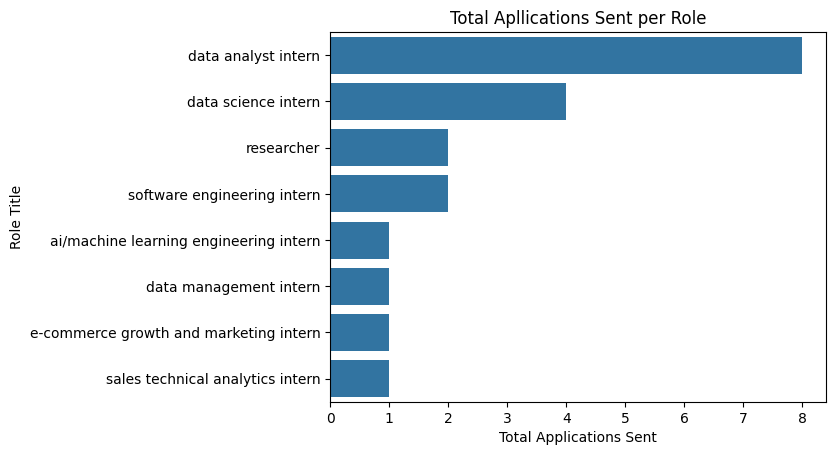

In [173]:
# creating DataFrameGroupBy object to keep count of number of applications per role
grouped_role = df.groupby("role").size().reset_index(name = "total").sort_values(by = "total", ascending = False) # grouping data based on role title, using size to keep count, reseting index to return Series object produced by size into DataFrame, and sorting values in descending order

# print text running totals
print(grouped_role)

# basic bar plot visualization of counts
sns.barplot(data = grouped_role, x = "total", y = "role")

# adjusting aesthetics: titles
plt.title("Total Apllications Sent per Role")
plt.xlabel("Total Applications Sent")
plt.ylabel("Role Title")

plt.show()

Same Data but Visualized Through Pie Chart

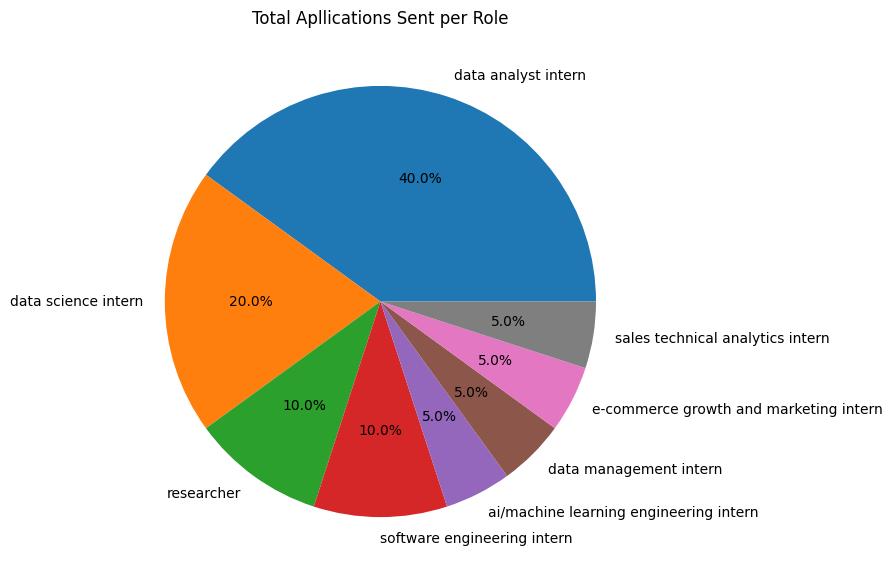

In [171]:
# aesthetic adjustments: size, plot title, etc...
plt.figure(figsize = (7,7))
plt.title("Total Apllications Sent per Role")

# creating pie chart
plt.pie(grouped_role["total"], labels = grouped_role["role"], autopct='%1.1f%%');

plt.show()